In [ ]:
import pandas as pd
import joblib

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [17]:
model = joblib.load(r"C:\Users\HEMANATH\Desktop\FIFA MATCH\models\xgb_match_predictor.pkl")
df = pd.read_csv(r"C:\Users\HEMANATH\Desktop\FIFA MATCH\data\processed\match_features.csv")
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,home_win_rate,away_win_rate,home_avg_goals,away_avg_goals,home_form,away_form,home_avg_conceded,away_avg_conceded,home_goal_diff,away_goal_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1,...,0.500000,0.500000,0.000000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,0,...,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333,0.000000,0.000000,0.000000,0.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,0,...,0.000000,0.500000,1.000000,2.000000,0.166667,0.666667,2.000000,1.000000,-1.000000,1.000000
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1,...,0.333333,0.333333,1.666667,1.333333,0.444444,0.444444,1.333333,1.666667,0.333333,-0.333333
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,0,...,0.250000,0.250000,1.500000,1.750000,0.416667,0.416667,1.750000,1.500000,-0.250000,0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49412,2026-06-13,Australia,Turkey,2.0,0.0,FIFA World Cup,Vancouver,Canada,True,0,...,0.509466,0.403427,2.008606,1.400312,0.466667,0.866667,1.065404,1.408100,0.943201,-0.007788
49413,2026-06-14,Germany,Curaçao,7.0,1.0,FIFA World Cup,Houston,United States,True,0,...,0.580989,0.371429,2.250242,1.649351,1.000000,0.266667,1.161979,1.579221,1.088264,0.070130
49414,2026-06-14,Ivory Coast,Ecuador,1.0,0.0,FIFA World Cup,Philadelphia,United States,True,0,...,0.511006,0.309645,1.638365,1.213198,0.800000,0.733333,0.996855,1.527919,0.641509,-0.314721
49415,2026-06-14,Netherlands,Japan,2.0,2.0,FIFA World Cup,Arlington,United States,True,1,...,0.515358,0.493671,2.094425,1.826582,0.666667,1.000000,1.224118,1.151899,0.870307,0.674684


In [18]:
X = df[[
    "home_team_enc",
    "away_team_enc",
    "tournament_enc",
    "neutral",
    "year",
    "month",
    "home_win_rate",
    "away_win_rate",
    "home_avg_goals",
    "away_avg_goals",
    "home_form",
    "away_form",
    "home_goal_diff",
    "away_goal_diff"
]]

y = df["result"]

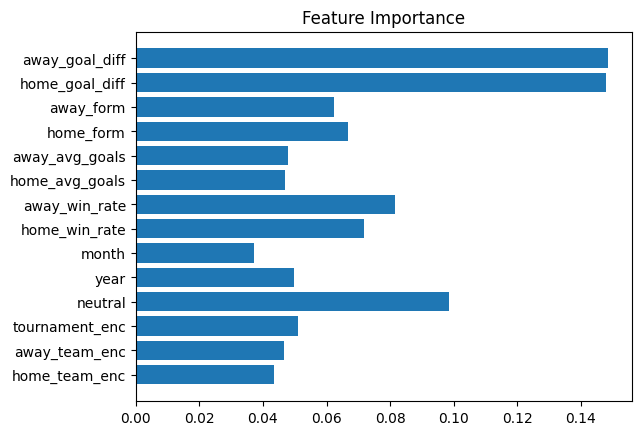

In [19]:
importances =model.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,shuffle=True)

XGB_model = XGBClassifier(n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="mlogloss")
XGB_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [22]:
y_pred = XGB_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5629299878591664


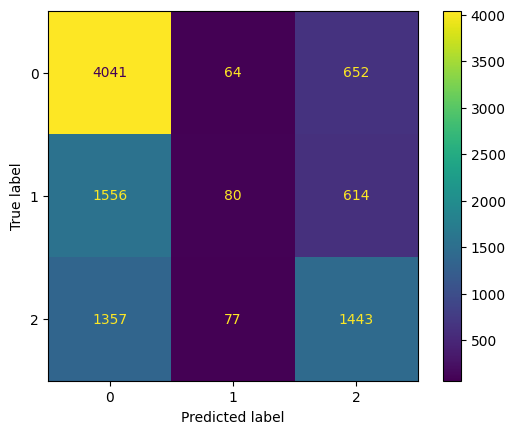

In [25]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()


In [26]:
sample = X_test.iloc[0:1]
print("Prediction:", model.predict(sample))
print("Probabilities:", model.predict_proba(sample))

Prediction: [2]
Probabilities: [[0.2811857  0.2534056  0.46540877]]
